### Este es un dataset sintético (creado artificialmente) que simula un portafolio de 1,000 clientes de una entidad financiera, como un banco o una plataforma de inversión. 📊

### El propósito principal de este dataset es educativo: fue diseñado específicamente para ilustrar los tres tipos de datos faltantes (MCAR, MAR y MNAR) que se discuten en ciencia de datos.

### Descripción de las Variables y sus Rangos:

### ***Cliente_ID***

#### Qué representa: Es un identificador numérico único para cada cliente. Actúa como la "llave primaria" de la tabla.

#### Rango: Números enteros (int) desde 1001 hasta 2000.

#### Datos Faltantes: Ninguno.

</br>

### ***Edad***

#### Qué representa: La edad del cliente en años.

#### Rango: Números enteros (int) generados aleatoriamente entre 20 y 69.

#### Datos Faltantes: Ninguno.

</br>


### ***Tipo_Cuenta***

#### Qué representa: La categoría o nivel de la cuenta que el cliente tiene en la institución. Esta es una variable categórica.

#### Rango (Valores posibles): 'Básica', 'Premium', o 'Inversión'.

#### Datos Faltantes: Ninguno. (Esta variable se usa para causar los datos faltantes en Ingreso_Anual).


</br>


### ***Ingreso_Anual***

#### Qué representa: El ingreso anual reportado por el cliente, en moneda.

#### Rango: Números decimales (float). El rango depende del Tipo_Cuenta para hacerlo más realista (ej. 'Básica' tiene ingresos entre 20,000-50,000, mientras 'Inversión' tiene entre 150,000-300,000).

#### Datos Faltantes: Sí (MAR - Faltante al Azar). La probabilidad de que este dato falte depende de la columna Tipo_Cuenta. Creamos la regla de que las cuentas 'Básica' omiten este dato mucho más (40% de las veces) que las cuentas 'Inversión' (solo 2%).

</br>


### ***Evaluacion_Riesgo***

#### Qué representa: Un "score" o puntaje numérico que evalúa el riesgo del cliente (similar a un puntaje de buró de crédito). Un número más alto significa más riesgo.

#### Rango: Números decimales (float) entre 300 (riesgo muy bajo) y 850 (riesgo muy alto).

#### Datos Faltantes: Sí (MNAR - Faltante No al Azar). Este es el caso más complejo. La probabilidad de que este dato falte depende de su propio valor. Configuramos que los clientes con puntajes muy altos (ej. > 750) tengan una alta probabilidad (50%) de no reportar su puntaje, mientras que los clientes de bajo riesgo casi siempre lo reportan (falta solo 5% de las veces).

</br>

### ***Ultima_Conexion_Region***

#### Qué representa: La región geográfica desde donde el cliente se conectó por última vez. Esta es una variable categórica.

#### Rango (Valores posibles): 'Norte', 'Sur', 'Centro', 'Este'.

#### Datos Faltantes: Sí (MCAR - Faltante Completamente al Azar). Un pequeño porcentaje (5%) de estos datos falta de forma totalmente aleatoria. Esto simula un error técnico o un fallo en el servidor que no tiene relación con el cliente, su cuenta ni ninguna otra variable.

Análisis de 'dataset_sintetico_app_finanicera.csv'

Funcion .info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Cliente_ID              1000 non-null   int64  
 1   Edad                    1000 non-null   int64  
 2   Tipo_Cuenta             1000 non-null   object 
 3   Ultima_Conexion_Region  950 non-null    object 
 4   Ingreso_Anual           758 non-null    float64
 5   Evaluacion_Riesgo       859 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 47.0+ KB

Funcion describe()
        Cliente_ID         Edad  Ingreso_Anual  Evaluacion_Riesgo
count  1000.000000  1000.000000     758.000000         859.000000
mean   1500.500000    44.830000  112646.803430         556.072177
std     288.819436    14.346809   77596.262953         146.221443
min    1001.000000    20.000000   20053.000000         3

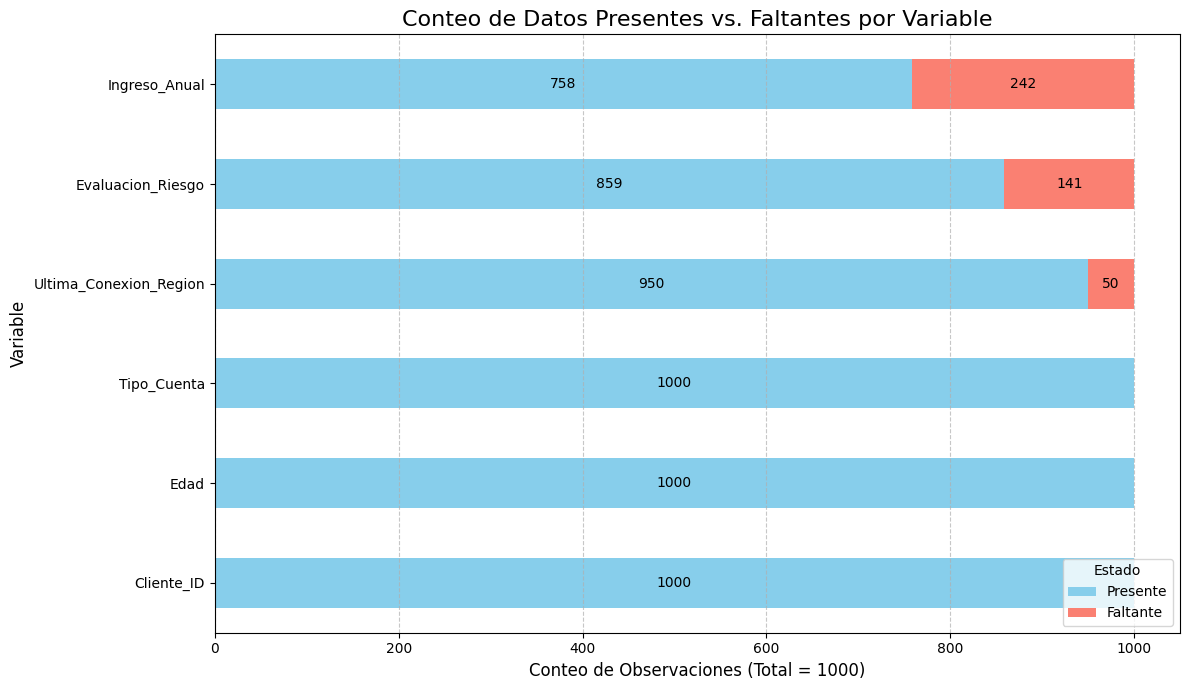

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# CARGA DEL DATA SET Y EDA BASICO

# Nombre del archivo CSV
file_name = 'dataset_sintetico_app_finanicera.csv'

try:
    # Cargar el dataset
    df = pd.read_csv(file_name)

    print(f"Análisis de '{file_name}'")

    # .info() nos da un resumen de tipos de datos y nulos
    print("\nFuncion .info()")
    df.info()

    # .describe() para estadísticas de variables numéricas
    print("\nFuncion describe()")
    print(df.describe())

    # .describe(include='object') para estadísticas de variables categóricas
    print("\nFuncion .describe() (Categórico)")
    print(df.describe(include='object'))

    # Conteo específico de nulos por columna
    print("\nFuncion Conteo de Nulos (isnull().sum())")
    missing_sum = df.isnull().sum()
    print(missing_sum)

    # Generación de la Gráfica

    print("\nGenerancion de gráfica de datos faltantes")

    # 1. Preparar los datos para la gráfica
    # Contamos los datos presentes
    present_counts = df.notnull().sum()

    # Creamos un nuevo DataFrame para la gráfica
    plot_df = pd.DataFrame({
        'Presente': present_counts,
        'Faltante': missing_sum
    })

    # Ordenar por total de faltantes para una mejor visualización
    plot_df = plot_df.sort_values(by='Faltante', ascending=True)

    # 2. Crear la gráfica de barras apiladas horizontal
    colors = ['skyblue', 'salmon'] # Celeste para 'Presente', Salmón para 'Faltante'

    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 7))

    # Generar la gráfica
    plot_df.plot(
        kind='barh',
        stacked=True,
        color=colors,
        ax=ax
)

    # Configurar títulos y etiquetas
    ax.set_title('Conteo de Datos Presentes vs. Faltantes por Variable', fontsize=16)
    ax.set_xlabel('Conteo de Observaciones (Total = 1000)', fontsize=12)
    ax.set_ylabel('Variable', fontsize=12)

    # Configurar leyenda
    ax.legend(title='Estado', loc='lower right')

    # Añadir cuadrícula para legibilidad
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    # Añadir los valores numéricos a las barras
    for container in ax.containers:
        for patch in container.patches:
            width = patch.get_width()
            if width > 0: # Solo añadir texto si la barra tiene ancho (hay datos)
                ax.text(patch.get_x() + width/2., patch.get_y() + patch.get_height()/2.,
                        '%d' % int(width),
                        ha='center', va='center',
                        color='black', fontsize=10)

    # Optimizar el layout
    plt.tight_layout()

    # Mostrar la gráfica
    plt.show()

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{file_name}'.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")